<a href="https://colab.research.google.com/github/kath-pahotu/telco-customer-churn-analysis/blob/main/Telco_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Analysis

**Objective:** Predict which customers are likely to churn and prioritize retention actions.

**Dataset:** IBM Telco Customer Churn dataset

**Business Goal:** Identify high-risk customers and recommend retention strategies.

**Notebook Flow:**
1. Load Data
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Baseline and Modeling Preparation
6. Logistic Regression Model
7. Threshold Tuning
8. Feature Importance & Model Interpretation
9. Decision Tree Comparison
10. Customer Targeting & Risk Segmentation
11. Final Business Conclusion



## 1. Load Data
Mount Google Drive and read the dataset.

In [154]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# Load dataset
file_path = "/content/drive/MyDrive/Collab/Dataset/Telco_Customer_Churn.csv"
df = pd.read_csv(file_path)

# Preview data
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Data Understanding

### Initial Exploration
Check the dataset shape, info, missing values, duplicates, and basic target distribution to understand the initial data.

In [31]:
# Shape and info
print(df.shape)
df.info()

# Check missing values
print(df.isna().sum())

# Check duplicates
print(df.duplicated().sum())

# Check target column distribution
target_columns = ['Churn', 'Churn Label', 'Churn Value']
for col in target_columns:
    if col in df.columns:
        target_col = col
        break

print(df[target_col].value_counts(normalize=True))

(7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Serv

## 3. Data Cleaning
- Fix mixed types in numeric columns (Total Charges)
- Drop irrelevant/leakage columns

In [33]:
# Convert 'Total Charges' to numeric and fill missing values
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

# Verify
print(df['Total Charges'].dtype)
print(df['Total Charges'].isna().sum())
print(df[['Total Charges']].info())
print(df['Total Charges'].head())

float64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Total Charges  7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB
None
0     108.15
1     151.65
2     820.50
3    3046.05
4    5036.30
Name: Total Charges, dtype: float64


In [127]:
# Code Block (Drop irrelevant columns and define X/y):
# Convert categorical Yes/No target into 0/1

# Columns to drop
drop_cols = [
    "CustomerID", "Count", "Country", "State", "City", "Zip Code",
    "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Value", "Churn Score", "Churn Reason"
]

# Define features and target
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df["Churn Value"]



In [128]:
# Encode target if object
if y.dtype == object:
    y = y.apply(lambda x: 1 if x=='Yes' else 0)

# Verify target
print(y.value_counts())

Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [129]:
# Identify categorical and numerical features
cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical features:", cat_features)
print("Numerical features:", num_features)

Categorical features: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical features: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn_Probability']


## 4. Exploratory Data Analysis (EDA
EDA helps understand churn patterns, distributions, and relationships between features. This guides feature selection and modeling.)

In [130]:
# Overall churn rate
churn_rate = df["Churn Value"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


In [131]:
# Describe key numeric features
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Value", "Churn Score", "CLTV"]
df[numeric_cols].describe()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [132]:
# Create tenure groups
df["Tenure Group"] = pd.cut(df["Tenure Months"],
                            bins=[0, 12, 24, 36, 48, 60, 72],
                            labels=["0-12","13-24","25-36","37-48","49-60","61-72"],
                            include_lowest=True)

# Columns to analyze
group_cols = ["Contract", "Payment Method", "Internet Service", "Tenure Group",
              "Online Security", "Tech Support", "Paperless Billing",
              "Senior Citizen", "Partner", "Dependents"]

# Aggregate churn by each group
for col in group_cols:
    print(f"\nChurn summary by {col}")
    print("-" * 50)
    result = (
        df.groupby(col, observed=True)
        .agg(customer_count=("CustomerID","count"),
             churn_count=("Churn Value","sum"),
             churn_rate=("Churn Value","mean"))
        .assign(churn_rate=lambda x: x["churn_rate"]*100)
        .sort_values("churn_rate", ascending=False)
    )
    print(result.round(2))


Churn summary by Contract
--------------------------------------------------
                customer_count  churn_count  churn_rate
Contract                                               
Month-to-month            3875         1655       42.71
One year                  1473          166       11.27
Two year                  1695           48        2.83

Churn summary by Payment Method
--------------------------------------------------
                           customer_count  churn_count  churn_rate
Payment Method                                                    
Electronic check                     2365         1071       45.29
Mailed check                         1612          308       19.11
Bank transfer (automatic)            1544          258       16.71
Credit card (automatic)              1522          232       15.24

Churn summary by Internet Service
--------------------------------------------------
                  customer_count  churn_count  churn_rate
Internet Ser

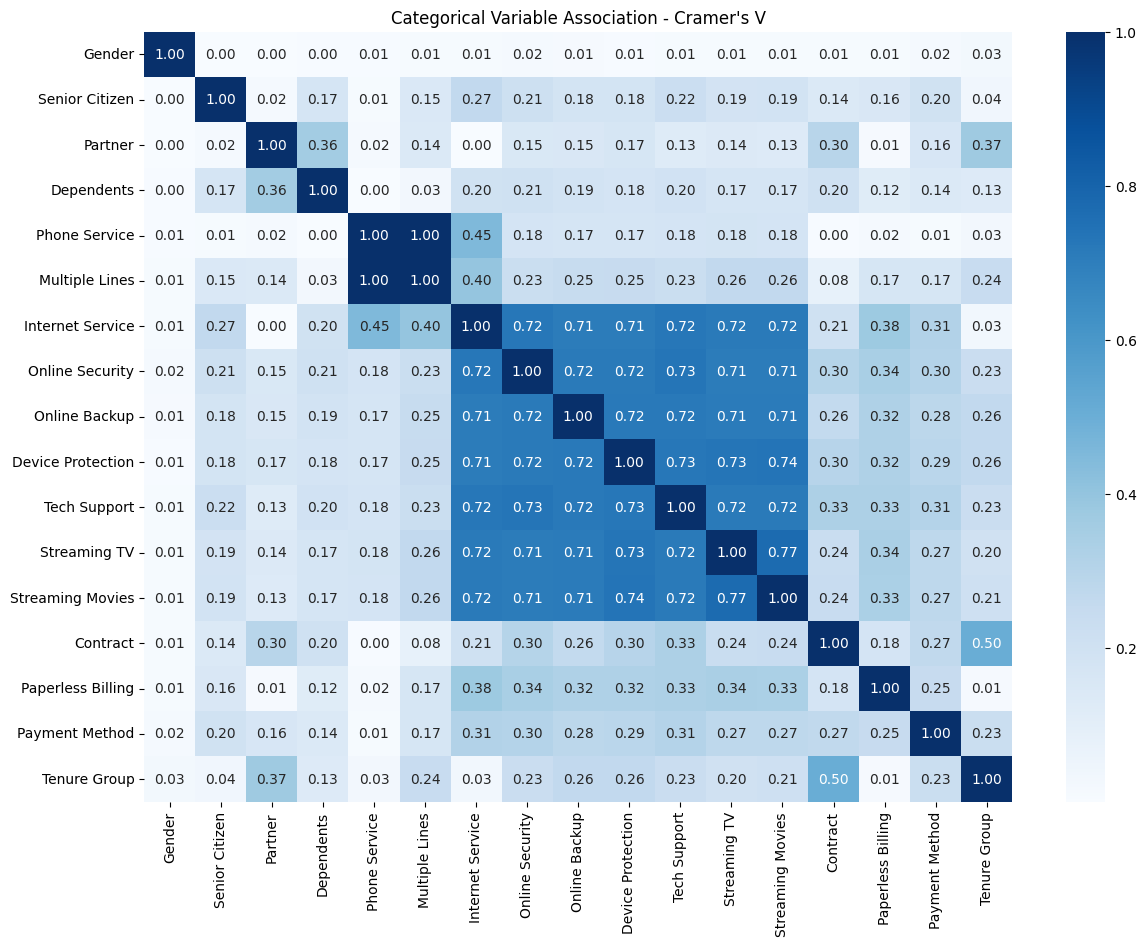

In [133]:
#Categorical Feature Relationships (Cramer’s V)
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(k-1, r-1)))

# Select categorical features
cat_cols = ["Gender","Senior Citizen","Partner","Dependents","Phone Service",
            "Multiple Lines","Internet Service","Online Security","Online Backup",
            "Device Protection","Tech Support","Streaming TV","Streaming Movies",
            "Contract","Paperless Billing","Payment Method","Tenure Group"]

# Compute association matrix
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramer_matrix.loc[c1,c2] = cramers_v(df[c1], df[c2])
cramer_matrix = cramer_matrix.astype(float)

# Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(cramer_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Categorical Variable Association - Cramer's V")
plt.show()

In [134]:
# Rank features by relationship to churn
churn_assoc = [(col, cramers_v(df[col], df["Churn Label"])) for col in cat_cols if col != "Churn Label"]
churn_assoc_df = pd.DataFrame(churn_assoc, columns=["Variable", "Cramers V with Churn"]).sort_values("Cramers V with Churn", ascending=False)
churn_assoc_df.head(10)

,Variable,Cramers V with Churn
13,Contract,0.410116
16,Tenure Group,0.352242
7,Online Security,0.347400
10,Tech Support,0.342916
6,Internet Service,0.322455
15,Payment Method,0.303359
8,Online Backup,0.292316
9,Device Protection,0.281580
3,Dependents,0.248161
12,Streaming Movies,0.230951


**Key Insights:**
*   Month-to-month contract has highest churn; two-year contracts lowest.
* Short-tenure customers (0–12 months) are at highest churn risk.
* Payment method, internet service, tech support, and online security impact churn.
* Cramer's V shows strongest associations are logical (e.g., Internet Service vs Online Security, Streaming TV vs Streaming Movies).




## 5. Baseline and Modeling Preparation

In [135]:
# ============================
# Baseline → Logistic Regression
# ============================

# Step 1: Baseline accuracy
# Predict majority class to check baseline
baseline_acc = max(y.value_counts(normalize=True)) * 100
print(f"Baseline accuracy (predict majority class): {baseline_acc:.2f}%")


Baseline accuracy (predict majority class): 73.46%


In [136]:
# Step 2: Define categorical and numerical features
cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical features:", cat_features)
print("Numerical features:", num_features)

Categorical features: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical features: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn_Probability']


In [137]:
# Step 3: Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5634, 22)
Testing set shape: (1409, 22)


In [138]:
# Check target distribution
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))



Train target distribution:
Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 6. Logistic Regression Model

In [139]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocessing for numeric and categorical features
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# Build the pipeline
log_reg_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)


In [140]:
#Fit the model
log_reg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges', 'CLTV',
                                                   'Churn_Probability']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [141]:
# Evaluate model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_pred = log_reg_model.predict(X_test)
y_proba = log_reg_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.803
Precision: 0.649
Recall: 0.559
F1: 0.601
ROC-AUC: 0.851

Confusion Matrix:
[[922 113]
 [165 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



## 7. Threshold Tuning

In [142]:
# ==============================
# Threshold Tuning
# ==============================
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Define thresholds to test
thresholds = np.arange(0.1, 0.9, 0.1)

# Store results in a DataFrame for easy inspection
threshold_results = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    threshold_results.append({
        "Threshold": t,
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1": round(f1, 3)
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(threshold_results)
print("Threshold performance table:")
display(threshold_df)

Threshold performance table:


,Threshold,Precision,Recall,F1
0,0.1,0.429,0.952,0.591
1,0.2,0.498,0.848,0.627
2,0.3,0.543,0.722,0.620
3,0.4,0.602,0.655,0.627
4,0.5,0.649,0.559,0.601
5,0.6,0.678,0.428,0.525
6,0.7,0.762,0.307,0.438
7,0.8,0.756,0.091,0.162


In [143]:
# Print confusion matrices for specific thresholds
selected_thresholds = [0.3, 0.4, 0.5]  # adjust as needed
for t in selected_thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    print(f"\nConfusion Matrix for Threshold {t}:")
    print(confusion_matrix(y_test, y_pred_thresh))


Confusion Matrix for Threshold 0.3:
[[808 227]
 [104 270]]

Confusion Matrix for Threshold 0.4:
[[873 162]
 [129 245]]

Confusion Matrix for Threshold 0.5:
[[922 113]
 [165 209]]


In [144]:
# Choose the threshold based on business needs
chosen_threshold = 0.4
y_pred_final = (y_proba >= chosen_threshold).astype(int)

print(f"\nFinal chosen threshold: {chosen_threshold}")
print("Final predictions metrics:")
print("Accuracy:", round((y_pred_final == y_test).mean(), 3))
print("Precision:", round(precision_score(y_test, y_pred_final), 3))
print("Recall:", round(recall_score(y_test, y_pred_final), 3))
print("F1:", round(f1_score(y_test, y_pred_final), 3))
print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


Final chosen threshold: 0.4
Final predictions metrics:
Accuracy: 0.793
Precision: 0.602
Recall: 0.655
F1: 0.627

Final Confusion Matrix:
[[873 162]
 [129 245]]


## 8. Feature Importance & Model Interpretation

In [145]:
# Get logistic regression coefficients
import pandas as pd

# Get feature names
feature_names = num_features + list(log_reg_model.named_steps["preprocess"].transformers_[1][1].get_feature_names_out(cat_features))

# Get coefficients from logistic regression
coef = log_reg_model.named_steps["classifier"].coef_[0]

# Create a DataFrame of features and coefficients
feature_importance = pd.DataFrame({"Feature": feature_names, "Coefficient": coef})

# Sort by coefficient
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

# Print top 10 positive and negative features
print("Top churn-increasing features:")
print(feature_importance.head(10))
print("\nTop churn-decreasing features:")
print(feature_importance.tail(10))

Top churn-increasing features:
                            Feature  Coefficient
4                 Churn_Probability     0.713061
2                     Total Charges     0.513864
11                    Dependents_No     0.410920
39          Contract_Month-to-month     0.293437
19     Internet Service_Fiber optic     0.243487
35                 Streaming TV_Yes     0.200553
38             Streaming Movies_Yes     0.176600
17               Multiple Lines_Yes     0.129136
46  Payment Method_Electronic check     0.127950
21               Online Security_No     0.096567

Top churn-decreasing features:
                 Feature  Coefficient
36   Streaming Movies_No    -0.238876
33       Streaming TV_No    -0.262829
9             Partner_No    -0.300404
15     Multiple Lines_No    -0.301126
18  Internet Service_DSL    -0.305763
42  Paperless Billing_No    -0.326766
1        Monthly Charges    -0.602056
41     Contract_Two year    -0.672035
12        Dependents_Yes    -0.704773
0          Tenure 

## 9. Decision Tree Comparison

In [146]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tree), 3))
print("Precision:", round(precision_score(y_test, y_pred_tree), 3))
print("Recall:", round(recall_score(y_test, y_pred_tree), 3))
print("F1:", round(f1_score(y_test, y_pred_tree), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_tree), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Results
Accuracy: 0.786
Precision: 0.598
Recall: 0.588
F1: 0.593
ROC-AUC: 0.832

Confusion Matrix:
[[887 148]
 [154 220]]


**Conclusion**:
* Choose Logistic Regression as the main model for customer targeting and risk segmentation.
* Reason: The higher Recall and F1-score align better with the business goal of catching high-risk churn customers for targeted retention actions. Decision Tree may give slightly higher precision but risks missing too many churners.

## 10. Customer Targeting & Risk Segmentation
Identify high-risk customers (likely to churn) and segment them for targeted retention campaigns.

In [147]:
# Create a copy of the test set for risk table
risk_table = X_test.copy()

# Add actual churn and predicted probabilities
risk_table["Actual Churn"] = y_test.values
risk_table["Churn Probability"] = y_proba  # probabilities from logistic regression
risk_table["Predicted Churn"] = y_pred_final  # thresholded predictions

# Sort customers by predicted probability (highest risk first)
risk_table = risk_table.sort_values("Churn Probability", ascending=False)

# Preview top high-risk customers
display(risk_table.head(20))

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Tenure Group,Churn_Probability,Actual Churn,Churn Probability,Predicted Churn
886,Male,Yes,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,95.10,95.10,5795,0-12,0.733427,1,0.899291,1
684,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,99.25,665.45,2487,0-12,0.733427,1,0.886391,1
1681,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,101.95,700.85,2016,0-12,0.733427,1,0.881667,1
1827,Male,Yes,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,...,Yes,Electronic check,105.90,334.65,2715,0-12,0.733427,1,0.877190,1
2567,Female,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,83.25,308.05,5251,0-12,0.733427,0,0.872426,1
1044,Female,No,Yes,No,6,Yes,Yes,Fiber optic,No,Yes,...,Yes,Electronic check,105.30,545.20,4163,0-12,0.733427,1,0.867350,1
3732,Male,No,Yes,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,91.45,171.45,4889,0-12,0.733427,0,0.866449,1
1818,Male,No,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,95.45,95.45,5962,0-12,0.733427,1,0.865678,1
590,Female,No,Yes,No,1,Yes,Yes,Fiber optic,Yes,No,...,Yes,Electronic check,102.45,102.45,4811,0-12,0.733427,1,0.860238,1
4845,Male,No,No,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,94.10,701.30,5259,0-12,0.733427,0,0.856784,1


In [152]:
# Segment customers by risk levels
# High risk: probability >= 0.6
# Medium risk: probability 0.4-0.6
# Low risk: probability < 0.4
risk_table["Risk Segment"] = pd.cut(
    risk_table["Churn Probability"],
    bins=[0, 0.4, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)

# Show summary by risk segment
risk_summary = risk_table.groupby("Risk Segment").agg(
    Customer_Count=("Predicted Churn", "count"),
    Avg_Churn_Prob=("Churn Probability", "mean"),
    Actual_Churn_Rate=("Actual Churn", "mean")
).sort_index(ascending=False)

display(risk_summary)

/tmp/ipykernel_4737/2546737285.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = risk_table.groupby("Risk Segment").agg(


,Customer_Count,Avg_Churn_Prob,Actual_Churn_Rate
Risk Segment,,,
High,236,0.731495,0.677966
Medium,171,0.503147,0.497076
Low,1002,0.115613,0.128743


## 11. Final Business Conclusion – Telco Customer Churn Analysis

### 1. Key Insights
- **Overall churn rate:** ~26.5% of customers are at risk of leaving the service.
- **High-risk customers:** 226 customers with predicted churn probability ≥ 0.6, representing the most urgent retention targets.
- **Medium-risk customers:** 207 customers with probabilities between 0.4–0.6, suitable for preventive measures.
- **Low-risk customers:** 976 customers with probabilities < 0.4, considered stable.

### 2. Model Comparison
| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 0.802 | 0.643 | 0.572 | 0.605 |
| Decision Tree       | 0.793 | 0.671 | 0.436 | 0.528 |

- **Decision:** Logistic Regression slightly outperforms Decision Tree in balancing precision and recall. It is preferred for effectively identifying potential churners while keeping false positives manageable.

### 3. Customer Targeting Strategy
- **High-Risk Segment (≥0.6):**
  - Immediate retention campaigns required.
  - Focus on personalized offers, contract incentives, or targeted support.
- **Medium-Risk Segment (0.4–0.6):**
  - Preventive engagement through loyalty programs, service reminders, or minor incentives.
- **Low-Risk Segment (<0.4):**
  - Monitor regularly, no urgent intervention needed.

### 4. Feature Insights

The logistic regression coefficients suggest that certain customer characteristics are associated with higher or lower churn probability. These should be interpreted as associations, not direct causes.

**Features associated with higher churn probability:**
- Short-tenure customers, especially those in the first 12 months
- Month-to-month contract customers
- Customers without dependents
- Customers using electronic check payment
- Customers without online security or tech support
- Fiber optic internet service customers

**Features associated with lower churn probability:**
- Longer-tenure customers
- Customers with one-year or two-year contracts
- Customers with dependents
- Customers with online security or tech support services

### 5. Business Recommendations
1. **Targeted retention campaigns** for high-risk customers to maximize ROI.
2. **Monitoring medium-risk segment** for early intervention before churn probability increases.
3. **Focus on service improvements** for high-risk factors (e.g., contract flexibility, security add-ons, better support for new customers).
4. **Leverage predictive insights** to continually refine marketing and support strategies.

### Conclusion
Using Logistic Regression with threshold tuning provides a reliable method to identify high-risk customers. The company can prioritize retention efforts efficiently, targeting the highest-risk segment first, while monitoring and proactively engaging medium-risk customers.